<a href="https://colab.research.google.com/github/nguyenduyvu61107/BTAINGUYENDUYVU2026/blob/main/Nh%E1%BA%ADn_di%E1%BB%87n_ch%E1%BB%89_tay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import shutil
import glob
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

# Kiểm tra GPU Cuda thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Đang sử dụng thiết bị: {device}")

# ---- CẤU HÌNH KAGGLE API MỚI (DÁN TOKEN DẠNG TEXT) ----
# BỒ DÁN CÁI MÃ TOKEN ĐÃ COPY VÀO TRONG DẤU NHÁY ĐƠN DƯỚI ĐÂY NHA:
KAGGLE_TOKEN = 'KGAT_355348829cd1bd23e99c842b1843a6b4'

# Thiết lập biến môi trường để kagglehub tự nhận diện
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN

# Tạo thư mục config theo chuẩn hệ thống
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_TOKEN)
!chmod 600 /root/.kaggle/access_token
print(" Cấu hình Kaggle API Token mới thành công!")

# ---- TẢI DATASET TỪ KAGGLEHUB ----
print("\nĐang tự động tải bộ dữ liệu 'saqibshoaibdz/palm-dataset' (Khoảng 8.5GB)...")
try:
    import kagglehub
    # Tải qua thư viện chính thức của Kaggle bằng Token vừa cấu hình
    saqibshoaibdz_palm_dataset_path = kagglehub.dataset_download('saqibshoaibdz/palm-dataset')
    print(f" Tải thành công! Dữ liệu gốc nằm tại: {saqibshoaibdz_palm_dataset_path}")

    # Gom các ảnh fomat .tiff hoặc .png sang thư mục local cho dễ xử lý
    db_dir = './database_images/'
    os.makedirs(db_dir, exist_ok=True)

    # Quét lấy khoảng 500 ảnh đại diện để chạy demo cho nhanh (tránh tràn RAM Colab)
    all_tiff_files = glob.glob(os.path.join(saqibshoaibdz_palm_dataset_path, '**', '*.tiff'), recursive=True)
    all_png_files = glob.glob(os.path.join(saqibshoaibdz_palm_dataset_path, '**', '*.png'), recursive=True)
    source_images = all_tiff_files + all_png_files

    print(f"Tìm thấy tổng cộng {len(source_images)} ảnh. Đang trích lấy ảnh làm Database mẫu...")
    for img_path in source_images[:5000]:
        shutil.copy(img_path, db_dir)
    print(f" Đã chuẩn bị xong thư mục cục bộ: {db_dir} với {len(os.listdir(db_dir))} ảnh.")

except Exception as e:
    print(f" Lỗi hệ thống khi tải data: {e}")

 Đang sử dụng thiết bị: cuda
 Cấu hình Kaggle API Token mới thành công!

Đang tự động tải bộ dữ liệu 'saqibshoaibdz/palm-dataset' (Khoảng 8.5GB)...


100%|██████████| 8.53G/8.53G [01:18<00:00, 117MB/s]

Extracting files...


 Tải thành công! Dữ liệu gốc nằm tại: /root/.cache/kagglehub/datasets/saqibshoaibdz/palm-dataset/versions/1
Tìm thấy tổng cộng 12000 ảnh. Đang trích lấy ảnh làm Database mẫu...
 Đã chuẩn bị xong thư mục cục bộ: ./database_images/ với 5000 ảnh.


In [3]:
def preprocess_palm_image(image_path, target_size=(224, 224), flip_horizontal=False):
    """
    Hàm tiền xử lý ảnh chỉ tay theo các bước giải thuật của bài nghiên cứu.
    """
    try:
        # 1. Đọc ảnh bằng OpenCV
        original_image = cv2.imread(image_path)
        if original_image is None:
            return None

        # 2. Chuyển đổi sang ảnh xám (Grayscale)
        gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

        # 3. Tăng cường độ tương phản cục bộ bằng CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(5, 5))
        enhanced_gray = clahe.apply(gray_image)

        # 4. Giảm nhiễu bằng Median Blur
        blurred_image = cv2.medianBlur(enhanced_gray, 3)

        # 5. Phân ngưỡng nhị phân (Thresholding) & Trích xuất đường biên (Contours)
        _, binary_image = cv2.threshold(blurred_image, 80, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return None

        # Tìm contour lớn nhất (đại diện cho toàn bộ lòng bàn tay)
        largest_contour = max(contours, key=cv2.contourArea)

        # 6. Trích xuất Vùng quan tâm (ROI) dựa trên Tâm khối (Centroid)
        M = cv2.moments(largest_contour)
        if M["m00"] == 0:
            return None
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        # Cắt một vùng hình vuông kích thước 276x276 quanh tâm cX, cY
        roi_size = 276
        half_size = roi_size // 2
        h, w = gray_image.shape

        start_y = max(0, cY - half_size)
        end_y = min(h, cY + half_size)
        start_x = max(0, cX - half_size)
        end_x = min(w, cX + half_size)

        roi = enhanced_gray[start_y:end_y, start_x:end_x]

        # 7. Chuyển đổi định dạng sang PIL Image để đồng bộ xử lý
        pil_img = Image.fromarray(roi).convert('RGB')

        # 8. Lật ảnh nếu có cấu hình cấu chọn (Đồng bộ hướng tay)
        if flip_horizontal:
            pil_img = ImageOps.mirror(pil_img)

        # 9. Resize về kích thước chuẩn và chuẩn hóa dạng mảng
        pil_img = pil_img.resize(target_size)

        return pil_img

    except Exception as e:
        print(f"Lỗi hệ thống tiền xử lý tại file {image_path}: {e}")
        return None

In [4]:
class PalmprintEncoder(nn.Module):
    def __init__(self, embedding_dim=256):
        super(PalmprintEncoder, self).__init__()
        # Load mô hình ResNet-18 có sẵn trọng số pre-trained từ ImageNet
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Giữ lại toàn bộ lớp CNN của ResNet-18, loại bỏ lớp phân loại tuyến tính cuối (fc)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])

        # Lấy số lượng node đầu vào của lớp fc cũ (thường là 512 với ResNet-18)
        in_features = resnet.fc.in_features

        # Khởi tạo Projection Head gồm 2 tầng Tuyến tính (MLP) có chèn ReLU ở giữa theo kiến trúc SimCLR
        self.projection_head = nn.Sequential(
            nn.Linear(in_features, in_features),
            nn.ReLU(),
            nn.Linear(in_features, embedding_dim)
        )

    def forward(self, x):
        # Đi qua các tầng trích xuất tích chập CNN
        features = self.encoder(x)
        # Làm phẳng đặc trưng (Flatten) từ dạng tensor 4D sang 2D
        features = features.flatten(1)
        # Đi qua đầu chiếu để nén lại thành vector 256 chiều
        embeddings = self.projection_head(features)
        return embeddings

# Khởi tạo mô hình và nạp vào cấu hình GPU (Cuda)
model = PalmprintEncoder(embedding_dim=256).to(device)
model.eval()  # Chuyển mô hình sang chế độ Evaluation (không tính gradient)
print(" Mô hình ResNet-18 CNN kết hợp Projection Head đã sẵn sàng trên GPU!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


 Mô hình ResNet-18 CNN kết hợp Projection Head đã sẵn sàng trên GPU!


In [5]:
# Định nghĩa chuẩn hóa tensor giống như chuẩn đầu vào của mạng ResNet
transform_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

db_features = []
db_image_paths = []

print("Bắt đầu quét thư mục và trích xuất đặc trưng... Vui lòng đợi...")

for img_name in os.listdir(db_dir):
    if img_name.lower().endswith(('jpg', 'jpeg', 'png', 'tiff')):
        img_path = os.path.join(db_dir, img_name)

        # Tiền xử lý ảnh gốc thành ảnh ROI (Dạng PIL Image)
        pil_img = preprocess_palm_image(img_path, flip_horizontal=False)

        if pil_img is not None:
            # Chuyển đổi sang Tensor PyTorch và nạp lên GPU
            img_tensor = transform_tensor(pil_img).unsqueeze(0).to(device)

            # Trích xuất vector đặc trưng không tính đạo hàm để tiết kiệm RAM
            with torch.no_grad():
                embedding = model(img_tensor).cpu().numpy().flatten()

            db_features.append(embedding)
            db_image_paths.append(img_path)

# Chuyển đổi danh sách đặc trưng thành ma trận numpy 2D
db_features = np.array(db_features)

# ===== KHÚC NÀY LÀ ĐỂ LƯU FILE LẠI NÈ BỒ =====
print("\n[INFO] Đang lưu kết quả đã học ra file để sau này dùng lại...")
np.save('db_features.npy', db_features)
np.save('db_image_paths.npy', np.array(db_image_paths))
torch.save(model.state_dict(), 'palm_model.pth')

print(" Đã lưu thành công 3 file: 'db_features.npy', 'db_image_paths.npy' và 'palm_model.pth'")
print(f" Tổng số lượng ảnh đã được học và lưu: {len(db_image_paths)}")

Bắt đầu quét thư mục và trích xuất đặc trưng... Vui lòng đợi...

[INFO] Đang lưu kết quả đã học ra file để sau này dùng lại...
 Đã lưu thành công 3 file: 'db_features.npy', 'db_image_paths.npy' và 'palm_model.pth'
 Tổng số lượng ảnh đã được học và lưu: 5000


Hãy upload hình ảnh chỉ tay bồ muốn mang đi đối chiếu so sánh:


Saving 2aOboQZYBxUZhSJ6S3batiGt95HBTSKvMJwyVBVA (1).jpg to 2aOboQZYBxUZhSJ6S3batiGt95HBTSKvMJwyVBVA (1).jpg


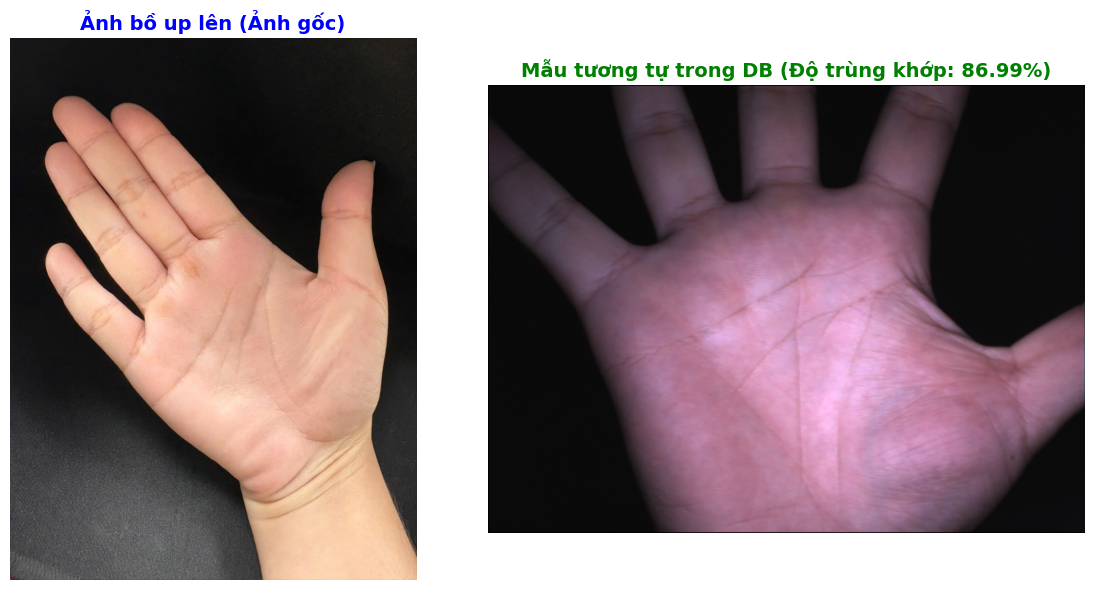

In [7]:
from google.colab import files

print("Hãy upload hình ảnh chỉ tay bồ muốn mang đi đối chiếu so sánh:")
uploaded_query = files.upload()

if uploaded_query:
    query_name = list(uploaded_query.keys())[0]

    # 1. Tiền xử lý ảnh test để lấy tensor đưa vào AI (vẫn giữ nguyên để AI trích xuất đặc trưng)
    query_pil = preprocess_palm_image(query_name, flip_horizontal=False)

    if query_pil is not None:
        # Biến đổi thành Tensor và dự đoán vector đặc trưng qua mô hình CNN
        query_tensor = transform_tensor(query_pil).unsqueeze(0).to(device)
        with torch.no_grad():
            query_embedding = model(query_tensor).cpu().numpy().reshape(1, -1)

        # Tính toán độ tương đồng Cosine Similarity giữa ảnh Test và toàn bộ Database
        scores = cosine_similarity(query_embedding, db_features)[0]

        # Tìm ra chỉ số của ảnh có điểm tương đồng cao nhất
        best_match_idx = np.argmax(scores)
        best_score = scores[best_match_idx]

        # ===== KHÚC ĐỔI SANG ẢNH GỐC CHƯA XỬ LÝ =====
        # Đọc ảnh bồ vừa up lên (Dạng ảnh gốc ban đầu)
        query_raw = Image.open(query_name)

        # Tìm đường dẫn và đọc ảnh tương đồng nhất gốc từ database
        best_match_path = db_image_paths[best_match_idx]
        best_match_raw = Image.open(best_match_path)

        # ---- HIỂN THỊ SONG SONG TRÁI - PHẢI KẾT QUẢ ----
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Bên Trái: Ảnh gốc bồ vừa up lên
        axes[0].imshow(query_raw)
        axes[0].set_title("Ảnh bồ up lên (Ảnh gốc)", fontsize=14, color='blue', fontweight='bold')
        axes[0].axis('off')

        # Bên Phải: Ảnh tương đồng nhất gốc trong Database
        axes[1].imshow(best_match_raw)
        axes[1].set_title(f"Mẫu tương tự trong DB (Độ trùng khớp: {best_score * 100:.2f}%)",
                          fontsize=14, color='green', fontweight='bold')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(" Lỗi: Hệ thống không thể định vị vùng lòng bàn tay. Vui lòng kiểm tra lại chất lượng ảnh chụp!")